Dados carregados. Formato: (85089, 7)
Período de Amostragem: 0.8s
     u     T0     T1     T2     T3     T4    t
0  0.0  27.56  29.18  29.18  27.62  29.25  0.0
1  0.0  27.56  29.18  29.18  27.68  29.25  0.8
2  0.0  27.56  29.18  29.18  27.68  29.25  1.6
3  0.0  27.56  29.18  29.18  27.68  29.25  2.4
4  0.0  27.56  29.18  29.18  27.68  29.25  3.2


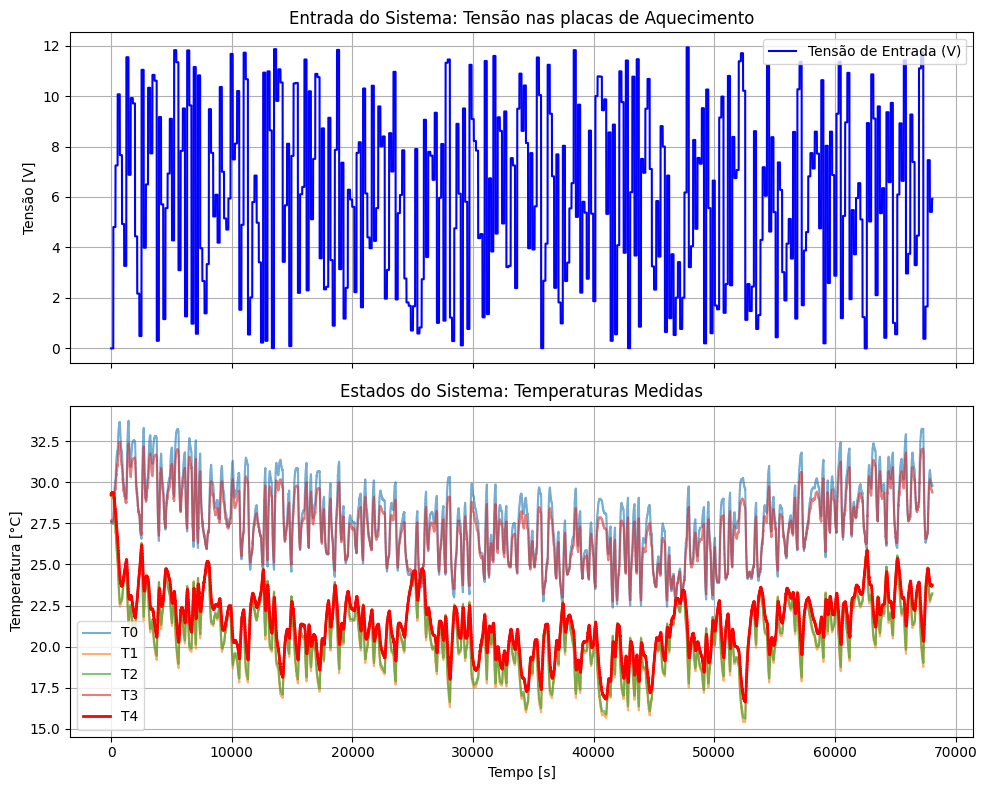

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the dataset
try:
    df = pd.read_csv('data.csv', header=None)
except FileNotFoundError:
    print("Error: 'data.csv' file not found.")
    exit(1)

# 2. Assign column names based on system description
# Col 0 = Input, Col 1..5 = Temperatures T0..T4
df.columns = ['u', 'T0', 'T1', 'T2', 'T3', 'T4']

# 3. Create Time Vector
Ts = 0.8 # Sampling period in seconds
df['t'] = df.index * Ts

# 4. Overview of the data
print(f"Dados carregados. Formato: {df.shape}")
print(f"Período de Amostragem: {Ts}s")
print(df.head())

# 5. Visualization
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot Input Voltage
ax[0].plot(df['t'], df['u'], color='blue', label='Tensão de Entrada (V)')
ax[0].set_ylabel('Tensão [V]')
ax[0].set_title('Entrada do Sistema: Tensão nas placas de Aquecimento')
ax[0].grid(True)
ax[0].legend()

# Plot Temperatures
ax[1].plot(df['t'], df['T0'], label='T0', alpha=0.6)
ax[1].plot(df['t'], df['T1'], label='T1', alpha=0.6)
ax[1].plot(df['t'], df['T2'], label='T2', alpha=0.6)
ax[1].plot(df['t'], df['T3'], label='T3', alpha=0.6)
ax[1].plot(df['t'], df['T4'], label='T4', color='red', linewidth=2)
ax[1].set_ylabel('Temperatura [°C]')
ax[1].set_xlabel('Tempo [s]')
ax[1].set_title('Estados do Sistema: Temperaturas Medidas')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.savefig('dados.png', dpi=300)
plt.show()

In [61]:
# Remove the first 5000 seconds and rebase time to start at 0
print("Remove os primeiros 5000 segundos dos dados para evitar transientes iniciais.")

df = df.loc[df['t'] >= 5000].copy().reset_index(drop=True)
df['t'] = df['t'] - 5000

print(f"Dados filtrados. Novo formato: {df.shape}")
print(df.head())

Remove os primeiros 5000 segundos dos dados para evitar transientes iniciais.
Dados filtrados. Novo formato: (78839, 7)
     u    T0     T1     T2     T3     T4    t
0  9.1  32.0  21.56  21.81  31.00  23.06  0.0
1  9.1  32.0  21.56  21.75  31.00  23.06  0.8
2  9.1  32.0  21.56  21.75  31.00  23.06  1.6
3  9.1  32.0  21.56  21.75  31.00  23.06  2.4
4  9.1  32.0  21.56  21.75  31.06  23.06  3.2


--- Resultados da Análise ---
Constante de Tempo Estimada (tau): 1089.60 s
Período de Amostragem Alvo (tau/4): 272.40 s
Período de Amostragem Original: 0.8 s
Fator de Decimação: 340
Novo Período de Amostragem: 272.00 s
Novo Formato do Conjunto de Dados: (232, 7)


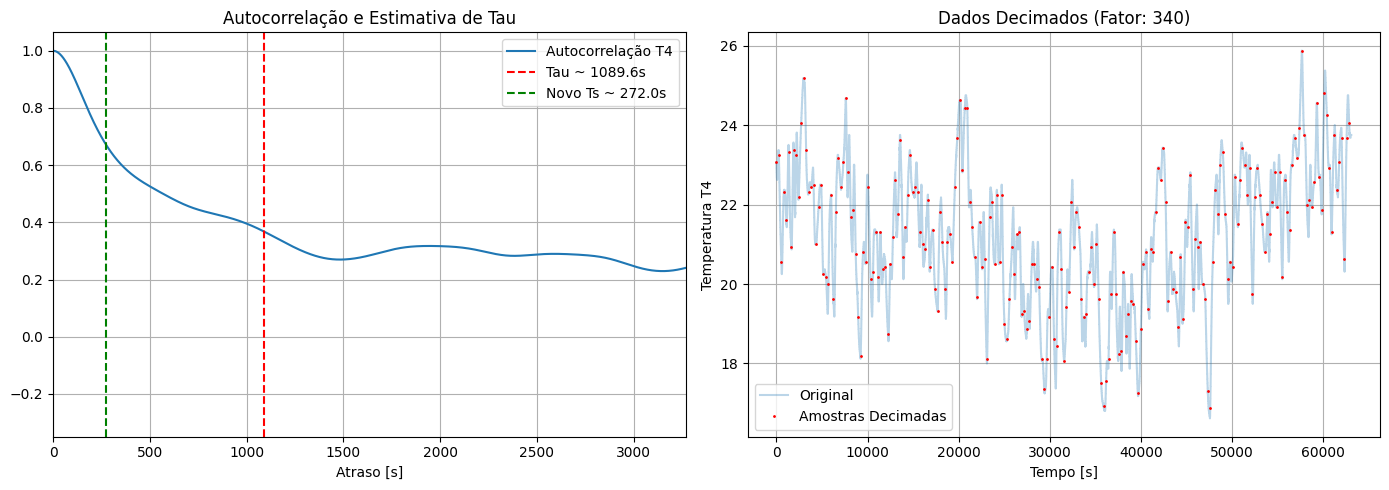

In [62]:
from scipy import signal

# --- 1. Data Analysis ---

# A. Autocorrelation Analysis to estimate Time Constant (tau)
# We look for the lag where autocorrelation drops to 1/e (~0.368)
y_centered = (df['T4'] - df['T4'].mean()).to_numpy()
# Compute autocorrelation
acf = np.correlate(y_centered, y_centered, mode='full')
acf = acf[len(acf)//2:] # Keep only positive lags
acf = acf / acf[0] # Normalize

# Find the lag (index) where ACF drops below 1/e
lags = np.arange(len(acf)) * Ts
try:
    tau_index = np.where(acf < np.exp(-1))[0][0]
    estimated_tau = lags[tau_index]
except IndexError:
    estimated_tau = lags[-1] # Fallback if signal is very slow

# B. Frequency Domain Analysis (PSD)
f, Pxx = signal.welch(y_centered, fs=1/Ts, nperseg=1024)

# --- 2. Determine Decimation Factor ---

# Rule of thumb: We want about 4 to 10 samples within one time constant.
target_Ts = estimated_tau / 4
decimation_factor = int(np.round(target_Ts / Ts))

# Ensure decimation is at least 1
if decimation_factor < 1:
    decimation_factor = 1

new_Ts = Ts * decimation_factor

# --- 3. Apply Decimation ---
# We use simple slicing [::N] to avoid adding phase lag from digital filters,
# which can complicate delay estimation later.
df_decimated = df.iloc[::decimation_factor].copy().reset_index(drop=True)

# --- 4. Visualization & Reporting ---
print(f"--- Resultados da Análise ---")
print(f"Constante de Tempo Estimada (tau): {estimated_tau:.2f} s")
print(f"Período de Amostragem Alvo (tau/4): {target_Ts:.2f} s")
print(f"Período de Amostragem Original: {Ts} s")
print(f"Fator de Decimação: {decimation_factor}")
print(f"Novo Período de Amostragem: {new_Ts:.2f} s")
print(f"Novo Formato do Conjunto de Dados: {df_decimated.shape}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Autocorrelation
ax[0].plot(lags, acf, label='Autocorrelação T4')
ax[0].axvline(estimated_tau, color='r', linestyle='--', label=f'Tau ~ {estimated_tau:.1f}s')
ax[0].axvline(new_Ts, color='g', linestyle='--', label=f'Novo Ts ~ {new_Ts:.1f}s')
ax[0].set_xlim(0, estimated_tau*3)
ax[0].set_title('Autocorrelação e Estimativa de Tau')
ax[0].set_xlabel('Atraso [s]')
ax[0].legend()
ax[0].grid(True)

# Plot Comparison of Raw vs Decimated
ax[1].plot(df['t'], df['T4'], label='Original', alpha=0.3)
ax[1].plot(df_decimated['t'], df_decimated['T4'], 'r.', markersize=2, label='Amostras Decimadas')
ax[1].set_title(f'Dados Decimados (Fator: {decimation_factor})')
ax[1].set_xlabel('Tempo [s]')
ax[1].set_ylabel('Temperatura T4')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.savefig('decimacao.png', dpi=300)
plt.show()

--- 1. Análise de Relevância ---
Média do Módulo da Correlação com T4: 0.4282
Correlações com T4:
u    -0.148947
T0   -0.068819
T1    0.948238
T2    0.962853
T3    0.011919
Name: T4, dtype: float64

Variáveis que excedem o limiar médio de correlação: ['T1', 'T2']

--- 2. Análise de Redundância (Limiar: 0.9) ---
Selecionado 'T2'
Excluindo 'T1': Altamente correlacionado (0.9981) com 'T2' selecionado

--- Seleção Final ---
Entradas Selecionadas: ['T2']
Alvo: T4


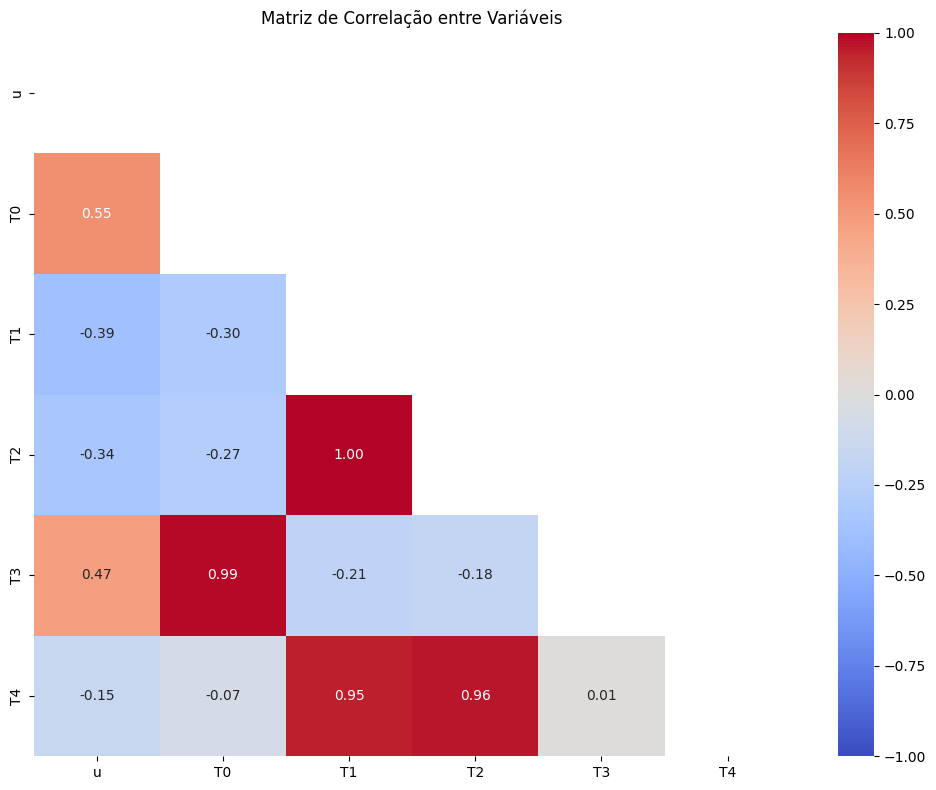

In [63]:
import seaborn as sns

# We use the decimated dataframe to avoid noise from oversampling
# The columns of interest are u, T0, T1, T2, T3 (candidates) and T4 (target)
candidates = ['u', 'T0', 'T1', 'T2', 'T3']
target = 'T4'

# 1. Compute Correlation Matrix
# We calculate correlation on the full set including target to see Input-Output and Input-Input relations
corr_matrix = df_decimated[candidates + [target]].corr()

# 2. Filter by Relevance (Correlation with Target)
# Extract correlations with T4 (excluding T4 itself)
target_corrs = corr_matrix[target].drop(target)
abs_target_corrs = target_corrs.abs()

# Calculate threshold (average of absolute correlations)
avg_corr = abs_target_corrs.mean()
relevant_vars = abs_target_corrs[abs_target_corrs > avg_corr].index.tolist()

print(f"--- 1. Análise de Relevância ---")
print(f"Média do Módulo da Correlação com {target}: {avg_corr:.4f}")
print("Correlações com T4:")
# Print correlations with T4, dropping last row
print(target_corrs)
print(f"\nVariáveis que excedem o limiar médio de correlação: {relevant_vars}")

# 3. Filter by Redundancy (Multicollinearity Check)
# We iterate through relevant variables and remove those highly correlated with an already selected variable
# Threshold for 'high' correlation between inputs (usually 0.85 to 0.95)
redundancy_threshold = 0.90
final_inputs = []

# Sort relevant variables by their correlation strength to T4 (descending)
# This ensures we prioritize the "best" predictor when choosing between two redundant ones.
sorted_candidates = abs_target_corrs[relevant_vars].sort_values(ascending=False).index.tolist()

print(f"\n--- 2. Análise de Redundância (Limiar: {redundancy_threshold}) ---")

for candidate in sorted_candidates:
    is_redundant = False
    for existing in final_inputs:
        # Check correlation between the current candidate and already selected inputs
        inter_corr = abs(corr_matrix.loc[candidate, existing])
        if inter_corr > redundancy_threshold: # type: ignore
            print(f"Excluindo '{candidate}': Altamente correlacionado ({inter_corr:.4f}) com '{existing}' selecionado")
            is_redundant = True
            break
    
    if not is_redundant:
        final_inputs.append(candidate)
        print(f"Selecionado '{candidate}'")

print(f"\n--- Seleção Final ---")
print(f"Entradas Selecionadas: {final_inputs}")
print(f"Alvo: {target}")

# 4. Visualization
plt.figure(figsize=(10, 8))
# Mask upper triangle for better readability
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matriz de Correlação entre Variáveis')
plt.tight_layout()
plt.savefig('matriz_correlacao.png', dpi=300)
plt.show()

# Update the working dataframe to contain only selected inputs + target + time
# This makes subsequent steps cleaner
selected_columns = ['t'] + final_inputs + [target]
df_modeling = df_decimated[selected_columns].copy()

Total de Amostras: 232
Conjunto de Teste:       35 amostras (15.1%)
Conjunto de Treinamento: 139 amostras (59.9%)
Conjunto de Validação:   58 amostras (25.0%)


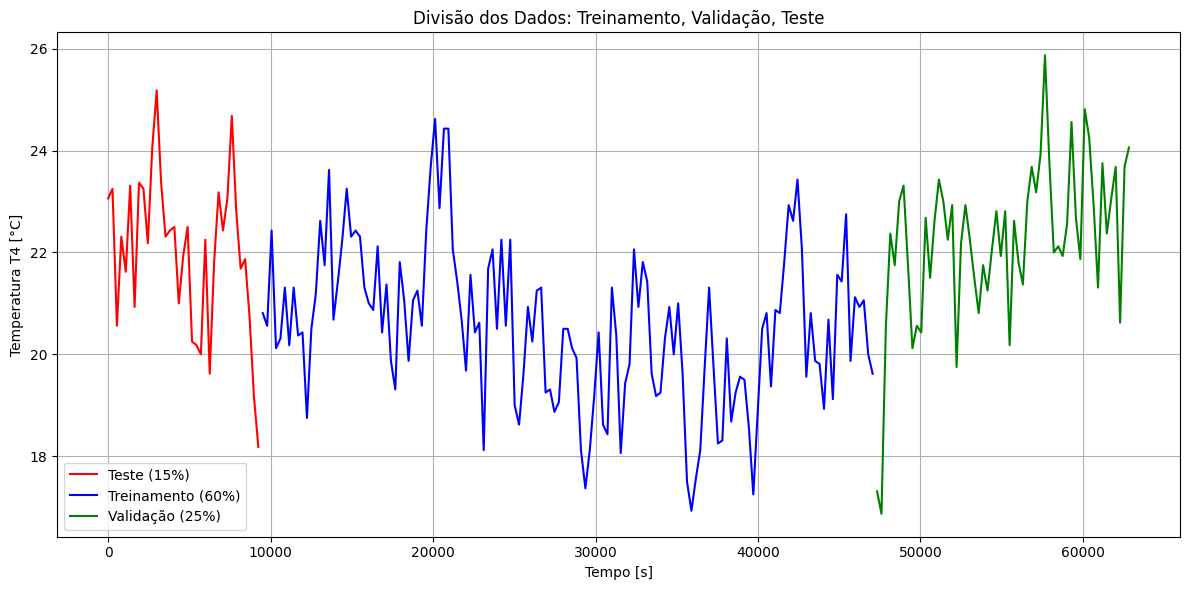

In [64]:
# Calculate split indices based on the fraction of total samples
N = len(df_decimated)
n_train = int(N * 0.60)
n_val = int(N * 0.25)
n_test = N - n_train - n_val  # Remaining 15%

# Perform the Sequential Split
# We use .copy() to ensure these are distinct dataframes, not views
test_df = df_decimated.iloc[:n_test].copy()
train_df = df_decimated.iloc[n_test:n_test+n_train].copy()
val_df = df_decimated.iloc[n_test+n_train:n_test+n_train+n_val].copy()


# Verify the splits
print(f"Total de Amostras: {N}")
print(f"Conjunto de Teste:       {len(test_df)} amostras ({len(test_df)/N:.1%})")
print(f"Conjunto de Treinamento: {len(train_df)} amostras ({len(train_df)/N:.1%})")
print(f"Conjunto de Validação:   {len(val_df)} amostras ({len(val_df)/N:.1%})")

# Visualization of the Split
plt.figure(figsize=(12, 6))

# We plot the Target (T4) to show the coverage
plt.plot(test_df['t'], test_df['T4'], label='Teste (15%)', color='red')
plt.plot(train_df['t'], train_df['T4'], label='Treinamento (60%)', color='blue')
plt.plot(val_df['t'], val_df['T4'], label='Validação (25%)', color='green')

plt.title('Divisão dos Dados: Treinamento, Validação, Teste')
plt.xlabel('Tempo [s]')
plt.ylabel('Temperatura T4 [°C]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('divisao_dos_dados.png', dpi=300)
plt.show()

In [65]:
import itertools
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA
import skfuzzy as fuzz
from skfuzzy.cluster import cmeans

import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# --- Configuration ---
# We use the test_df for structure determination
df_struct = test_df.reset_index(drop=True)
y_s = df_struct['T4'].to_numpy()
u_s = df_struct['T2'].to_numpy()
N_s = len(y_s)

# Max lags to test
max_lag = 6

# --- 1. Linear ARX Structure Selection (AIC) ---
print("--- 1. Seleção da Estrutura ARX ---")
best_aic_arx = np.inf
best_order_arx = None

# Grid search for ARX(na, nb) - assuming nk=1 (min delay)
for na in range(1, max_lag + 1):
    for nb in range(1, max_lag + 1):
        # Construct regressors
        # y(k) = -a1*y(k-1)... + b1*u(k-1)...
        # We lose max(na, nb) samples
        start_idx = max(na, nb)
        y_target = y_s[start_idx:]
        
        # Build phi matrix
        cols = []
        for i in range(1, na + 1): cols.append(y_s[start_idx-i : -i]) # y terms
        for i in range(1, nb + 1): cols.append(u_s[start_idx-i : -i]) # u terms
        
        X_mat = np.column_stack(cols)
        
        # Fit OLS
        model = LinearRegression().fit(X_mat, y_target)
        rss = np.sum((y_target - model.predict(X_mat))**2)
        n_params = na + nb
        n_samples = len(y_target)
        
        # Calculate AIC: N * ln(RSS/N) + 2*k
        aic = n_samples * np.log(rss/n_samples) + 2 * n_params
        
        if aic < best_aic_arx:
            best_aic_arx = aic
            best_order_arx = (na, nb)

print(f"Melhor Ordem ARX (na, nb): {best_order_arx} com AIC: {best_aic_arx:.2f}")


# --- 2. Linear ARMAX Structure Selection (AIC) ---
print("\n--- 2. Seleção da Estrutura ARMAX ---")
# ARMAX is effectively ARIMA(p, 0, q) with exogenous input
best_aic_armax = np.inf
best_order_armax = None

# Grid search (p=AR, q=MA). limiting range to save computation time
for p in range(1, 3):
    for q in range(1, 3):
        try:
            # We treat 'u' as exog. 
            # Note: ARIMA tends to be computationally heavy.
            model = ARIMA(y_s, order=(p, 0, q), exog=u_s)
            res = model.fit(method_kwargs={'warn_convergence': False})
            
            if res.aic < best_aic_armax:
                best_aic_armax = res.aic
                best_order_armax = (p, q)
        except:
            continue

print(f"Melhor Ordem ARMAX (p, q): {best_order_armax} com AIC: {best_aic_armax:.2f}")


# --- 3. Nonlinear Polynomial Structure (ERR) ---
print("\n--- 3. Estrutura Polinomial Não Linear (ERR) ---")
# Simplified Forward Regression with Orthogonal Least Squares (OLS)
# We consider a candidate pool of degree 2 polynomial terms from lags 1..2

# Generate candidate regressors (y_k-1, y_k-2, u_k-1, u_k-2)
lag_poly = 2
start_idx = lag_poly
y_t = y_s[start_idx:]
candidates = {}
names = []

# Base terms
for i in range(1, lag_poly+1):
    candidates[f'y(k-{i})'] = y_s[start_idx-i : -i]
    names.append(f'y(k-{i})')
    candidates[f'u(k-{i})'] = u_s[start_idx-i : -i]
    names.append(f'u(k-{i})')

# Cross terms (Degree 2)
base_names = names.copy()
for i in range(len(base_names)):
    for j in range(i, len(base_names)):
        key = f"{base_names[i]}*{base_names[j]}"
        candidates[key] = candidates[base_names[i]] * candidates[base_names[j]]
        names.append(key)

# ERR Algorithm (Simplified)
selected_terms = []
selected_indices = []
residual = y_t.copy()
total_variance = np.sum(y_t**2)

print("Selecionando os principais termos via Taxa de Redução de Erro (ERR):")
for step in range(3): # Select top 3 terms
    best_err = -1
    best_term = None
    
    for name in names:
        if name in selected_terms: continue
        
        # Regressor
        col = candidates[name]
        
        # Standard ERR calculation with orthogonalization
        # Project col onto residual space
        num = np.sum(residual * col)
        den = np.sum(col**2)
        
        if den != 0:
            # Contribution to variance explained
            err_contribution = (num**2) / den
            corr = err_contribution / total_variance
        else:
            corr = 0
        
        if corr > best_err:
            best_err = corr
            best_term = name
            
    if best_term:
        selected_terms.append(best_term)
        # Update residual by projecting out the selected term
        x_sel = candidates[best_term].reshape(-1, 1)
        coeffs = np.linalg.lstsq(x_sel, residual, rcond=None)[0]
        residual = residual - (x_sel @ coeffs).flatten()
        
        # Calculate approximate ERR for this step
        err_val = 1 - (np.sum(residual**2) / total_variance)
        print(f" Passo {step+1}: Adicionado '{best_term}'")

# --- 4. Fuzzy TS Structure (Clustering Coefficient) ---
print("\n--- 4. Seleção da Estrutura Fuzzy TS ---")
# We use Fuzzy C-Means on the input-output product space [y(k-1), u(k-1)]
# to determine the number of rules (clusters).

# Construct data Z = [y(k-1), u(k-1)].T for clustering
Z = np.vstack((y_s[:-1], u_s[:-1])) 

best_fpc = -1
best_c = 2
fpcs = []

# Test cluster counts from 2 to 7
c_range = range(2, 8)
for c in c_range:
    # cntr: centers, u_mem: membership, u0: initial, d: distance, jm: obj fun, p: iter, fpc: partition coeff
    cntr, u_mem, u0, d, jm, p, fpc = cmeans(Z, c, m=2, error=0.005, maxiter=1000, init=None)
    fpcs.append(fpc)
    if fpc > best_fpc:
        best_fpc = fpc
        best_c = c

print(f"Coeficientes de Partição Fuzzy (FPC) para c={list(c_range)}:")
print([float(round(x, 3)) for x in fpcs])
print(f"Melhor Número de Clusters (Regras): {best_c} (Maior FPC)")

--- 1. Seleção da Estrutura ARX ---
Melhor Ordem ARX (na, nb): (1, 6) com AIC: 11.39

--- 2. Seleção da Estrutura ARMAX ---
Melhor Ordem ARMAX (p, q): (1, 1) com AIC: 57.23

--- 3. Estrutura Polinomial Não Linear (ERR) ---
Selecionando os principais termos via Taxa de Redução de Erro (ERR):
 Passo 1: Adicionado 'y(k-1)'
 Passo 2: Adicionado 'u(k-1)*u(k-1)'
 Passo 3: Adicionado 'y(k-2)'

--- 4. Seleção da Estrutura Fuzzy TS ---
Coeficientes de Partição Fuzzy (FPC) para c=[2, 3, 4, 5, 6, 7]:
[0.865, 0.81, 0.766, 0.745, 0.704, 0.733]
Melhor Número de Clusters (Regras): 2 (Maior FPC)


In [66]:
# --- Configuration ---
# We use the Training Set
y_train = train_df['T4'].to_numpy()
u_train = train_df['T2'].to_numpy()
N_train = len(y_train)

# --- 1. ARX Parameter Estimation ---
print("--- 1. Estimação dos Parâmetros ARX ---")
assert best_order_arx is not None, "ordem ARX não determinada."
na, nb = best_order_arx
start_idx = max(na, nb)

# Construct Regressor Matrix (Phi)
cols = []
# Note: Sklearn LinearRegression adds the bias (intercept) automatically
for i in range(1, na + 1): cols.append(y_train[start_idx-i : -i])
for i in range(1, nb + 1): cols.append(u_train[start_idx-i : -i])

X_arx = np.column_stack(cols)
y_arx_target = y_train[start_idx:]

arx_model = LinearRegression()
arx_model.fit(X_arx, y_arx_target)

print(f"Coeficientes ARX: {arx_model.coef_}")
print(f"Interceção ARX: {arx_model.intercept_:.4f}")


# --- 2. ARMAX Parameter Estimation ---
print("\n--- 2. Estimação dos Parâmetros ARMAX ---")
# ARMAX is ARIMA(p, 0, q) with Exogenous Input
try:
    assert best_order_armax is not None, "ordem ARMAX não determinada."
    p, q = best_order_armax
    # We fit on the full training set.
    # statsmodels handles initial conditions internally.
    armax_model = ARIMA(y_train, order=(p, 0, q), exog=u_train)
    armax_results = armax_model.fit()
    print(armax_results.summary().tables[1])
except Exception as e:
    print(f"Estimação ARMAX falhou: {e}")


# --- 3. Polynomial (NARX) Parameter Estimation ---
print("\n--- 3. Estimação dos Parâmetros Polinomiais ---")
# Reconstruct only the selected terms from the previous step
# 'selected_terms' contains strings like 'y(k-1)' or 'u(k-1)*y(k-1)'
poly_cols = []
lag_poly = 2 # From previous step
start_idx_poly = lag_poly

# Helper to parse term and retrieve data
def get_term_data(term_name, y_data, u_data, start, end):
    # Simple parser for terms like "y(k-1)", "u(k-2)", "y(k-1)*u(k-1)"
    if '*' in term_name:
        parts = term_name.split('*')
        return get_term_data(parts[0], y_data, u_data, start, end) * \
               get_term_data(parts[1], y_data, u_data, start, end)
    
    # Base term extraction
    var = y_data if 'y' in term_name else u_data
    # Extract lag number from string "y(k-1)" -> 1
    lag_str = term_name.split('-')[1].replace(')', '')
    lag = int(lag_str)
    
    # Slicing: same logic as before [start-lag : -lag]
    # We need to handle the end index carefully. If end is 0 (last element), slicing is tricky.
    if end == 0: return var[start-lag:]
    return var[start-lag : -lag]

# Build Matrix
# Note: If start_idx_poly is used, the target y is y_train[start_idx_poly:]
# But we need to be consistent with the array lengths.
# Let's verify lengths. y_train has N samples. 
# Regressors will have N - start_idx_poly samples.
target_len = N_train - start_idx_poly

for term in selected_terms:
    # Use 0 as end index effectively implies taking until the end
    # We construct manual slice indices
    col_data = np.zeros(target_len)
    
    # Re-implementing generation loop for safety/clarity on indices
    # This ensures specific alignment
    for k in range(target_len):
        # Time index in original array
        t_idx = k + start_idx_poly
        
        # Parse term for specific t_idx
        # This is slower but safer for parsing generic strings "y(k-1)*u(k-2)"
        val = 1.0
        parts = term.split('*')
        for part in parts:
            var = y_train if 'y' in part else u_train
            lag = int(part.split('-')[1].replace(')', ''))
            val *= var[t_idx - lag]
        col_data[k] = val
        
    poly_cols.append(col_data)

X_poly = np.column_stack(poly_cols)
y_poly_target = y_train[start_idx_poly:]

poly_model = LinearRegression()
poly_model.fit(X_poly, y_poly_target)

print(f"Termos Polinomiais: {selected_terms}")
print(f"Coeficientes Polinomiais: {poly_model.coef_}")


# --- 4. Fuzzy TS Parameter Estimation ---
print("\n--- 4. Estimação dos Parâmetros Fuzzy TS ---")
# A. Antecedent (Membership) Estimation using Fuzzy C-Means
# Data Z for clustering: [y(k-1), u(k-1)]
# Aligns with standard TS inputs
Z_train = np.vstack((y_train[:-1], u_train[:-1]))
y_ts_target = y_train[1:]

# Run C-Means to get centers and membership matrix U
# cntr: (best_c, 2)
cntr, u_mem, _, _, _, _, _ = cmeans(Z_train, c=best_c, m=2, error=0.005, maxiter=1000)

print(f"Centros dos Clusters (Antecedentes):\n{cntr}")

# B. Consequent (Local Linear Models) Estimation
# Model: y(k) = a_i*y(k-1) + b_i*u(k-1) + c_i
# We use Weighted Least Squares (WLS) for each cluster i
# Weights are the membership values u_mem[i, :]

# Regressor matrix for local models: [y(k-1), u(k-1), 1]
X_ts = np.vstack((y_train[:-1], u_train[:-1], np.ones(len(y_train)-1))).T

ts_params = [] # List to store (a, b, c) for each rule

for i in range(best_c):
    # Weights for cluster i
    weights = u_mem[i, :]
    W = np.diag(weights)
    
    # WLS Solution: theta = (X'WX)^-1 X'Wy
    # Using sklean Sample Weights is easier and numerically stable
    local_model = LinearRegression()
    local_model.fit(X_ts[:, :2], y_ts_target, sample_weight=weights)
    
    params = np.append(local_model.coef_, local_model.intercept_) # [a, b, c]
    ts_params.append(params)
    print(f"Regra {i+1} Consequentes: [a={params[0]:.4f}, b={params[1]:.4f}, c={params[2]:.4f}]")

# Store Fuzzy Model structure for later use
fuzzy_model_data = {
    'centers': cntr,
    'params': np.array(ts_params)
}

--- 1. Estimação dos Parâmetros ARX ---
Coeficientes ARX: [-0.55793521  0.88529834  0.25565697  0.02501249  0.03308139 -0.05540422
  0.06981145]
Interceção ARX: 7.7914

--- 2. Estimação dos Parâmetros ARMAX ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.3206      0.452      7.352      0.000       2.435       4.206
x1             0.8638      0.023     37.795      0.000       0.819       0.909
ar.L1          0.0046      0.504      0.009      0.993      -0.983       0.992
ma.L1         -0.1799      0.491     -0.367      0.714      -1.141       0.782
sigma2         0.1972      0.027      7.309      0.000       0.144       0.250

--- 3. Estimação dos Parâmetros Polinomiais ---
Termos Polinomiais: ['y(k-1)', 'u(k-1)*u(k-1)', 'y(k-2)']
Coeficientes Polinomiais: [-0.45780227  0.0201965   0.3014665 ]

--- 4. Estimação dos Parâmetros Fuzzy TS ---
Centros dos Cluster

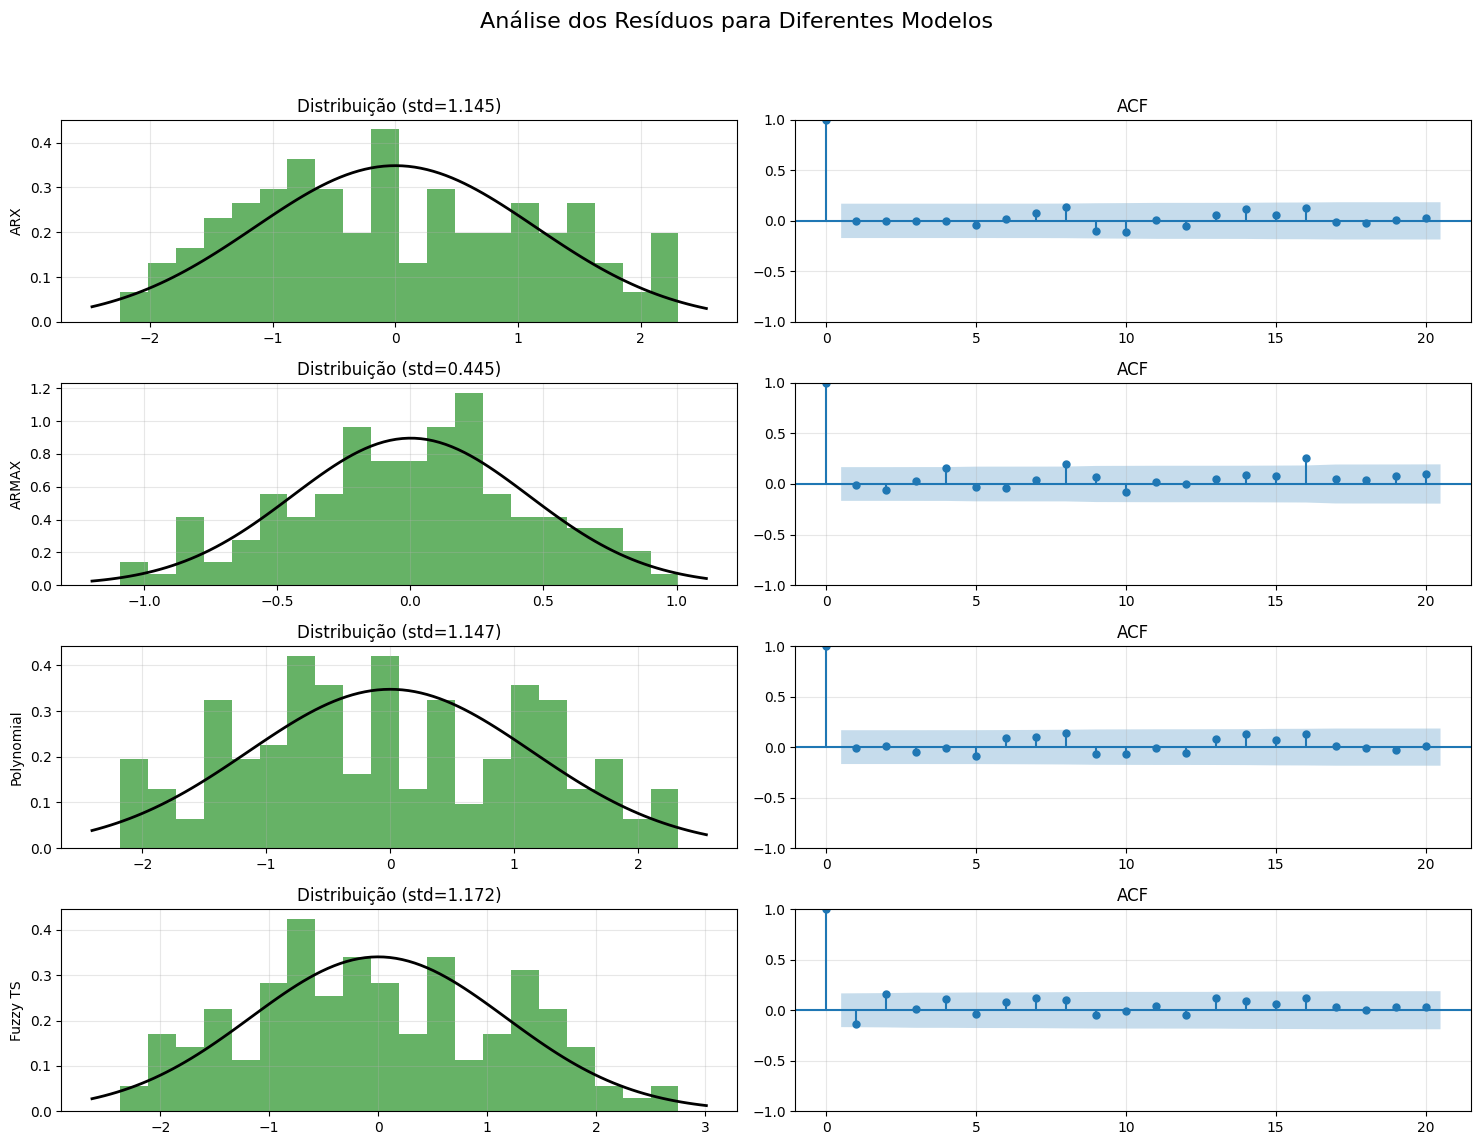

--- Erro Quadrático Médio (MSE) nos Dados de Treinamento ---
ARX MSE:        1.31034
ARMAX MSE:      0.19797
Polynomial MSE: 1.31580
Fuzzy TS MSE:   1.37463


In [72]:
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import norm

# --- Helper Function for Residual Computation ---
# We need to reconstruct predictions for the training set

# 1. ARX Residuals
y_pred_arx = arx_model.predict(X_arx)
resid_arx = y_arx_target - y_pred_arx

# 2. ARMAX Residuals
# statsmodels provides these directly
resid_armax = armax_results.resid
# Align length if necessary (remove initial diffs due to startup)
assert best_order_armax is not None, "ordem ARMAX não determinada."
resid_armax = resid_armax[max(best_order_armax):]

# 3. Polynomial Residuals
y_pred_poly = poly_model.predict(X_poly)
resid_poly = y_poly_target - y_pred_poly

# 4. Fuzzy TS Residuals
# We need to compute the weighted sum of the local models
# We reuse u_mem (membership) from the previous cell which corresponds to Training data
y_pred_fuzzy = np.zeros_like(y_ts_target)
# X_ts was [y(k-1), u(k-1), 1]
# params was [a, b, c]
for i in range(best_c):
    # Local linear prediction: a*y + b*u + c
    # Note: fuzzy_model_data['params'][i] = [a, b, c]
    # X_ts[:, :2] is [y, u]
    params = fuzzy_model_data['params'][i]
    y_local = (X_ts[:, 0] * params[0]) + (X_ts[:, 1] * params[1]) + params[2]
    
    # Weight by membership
    y_pred_fuzzy += u_mem[i, :] * y_local

resid_fuzzy = y_ts_target - y_pred_fuzzy

# --- Visualization Function ---
def plot_resid_analysis(residuals, model_name, ax_row):
    # 0. Model Name
    ax_row[0].set_ylabel(f'{model_name}')

    # 1. Histogram vs Normal Distribution
    mu, std = norm.fit(residuals)
    ax_row[0].hist(residuals, bins=20, density=True, alpha=0.6, color='g')
    xmin, xmax = ax_row[0].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    ax_row[0].plot(x, p, 'k', linewidth=2)
    ax_row[0].set_title(f'Distribuição (std={std:.3f})')
    ax_row[0].grid(True, alpha=0.3)
    
    # 2. Autocorrelation (ACF)
    plot_acf(residuals, ax=ax_row[1], lags=20, title=f'ACF')
    ax_row[1].grid(True, alpha=0.3)

# --- Plotting ---
fig, axes = plt.subplots(4, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.4)

plot_resid_analysis(resid_arx, "ARX", axes[0])
plot_resid_analysis(resid_armax, "ARMAX", axes[1])
plot_resid_analysis(resid_poly, "Polynomial", axes[2])
plot_resid_analysis(resid_fuzzy, "Fuzzy TS", axes[3])

plt.suptitle('Análise dos Resíduos para Diferentes Modelos', fontsize=16)
plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.savefig('analise_residuos.png', dpi=300)
plt.show()

# --- Quantitative Metrics (MSE) on Training Data ---
print("--- Erro Quadrático Médio (MSE) nos Dados de Treinamento ---")
print(f"ARX MSE:        {np.mean(resid_arx**2):.5f}")
print(f"ARMAX MSE:      {np.mean(resid_armax**2):.5f}")
print(f"Polynomial MSE: {np.mean(resid_poly**2):.5f}")
print(f"Fuzzy TS MSE:   {np.mean(resid_fuzzy**2):.5f}")

In [68]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import euclidean

# 1. Parameter Extraction

# Helper to safely extract statsmodels parameters by name from a numpy array
def get_sm_param(results_obj, param_name):
    # param_names is a list of strings like ['const', 'x1', 'ar.L1', 'ma.L1', 'sigma2']
    try:
        idx = results_obj.model.param_names.index(param_name)
        return results_obj.params[idx]
    except ValueError:
        # Fallback or strict error
        print(f"Aviso: Parâmetro '{param_name}' não encontrado em {results_obj.model.param_names}")
        return 0.0

# Extract ARX Parameters
# LinearRegression coefs are [y(k-1), u(k-1)] for ARX(1,1)
p_arx_intercept = arx_model.intercept_
p_arx_a1 = arx_model.coef_[0] # Coef for y(k-1)
p_arx_b1 = arx_model.coef_[1] # Coef for u(k-1)
params_arx = (p_arx_intercept, p_arx_a1, p_arx_b1)

# Extract ARMAX Parameters
# We need 'const', 'x1' (exogenous beta), and 'ar.L1' (phi)
# Note: Statsmodels defines this as Regression with ARIMA errors
p_armax_const = get_sm_param(armax_results, 'const')
p_armax_beta = get_sm_param(armax_results, 'x1')    # Coefficient for u
p_armax_phi = get_sm_param(armax_results, 'ar.L1')  # AR term
params_armax = (p_armax_const, p_armax_beta, p_armax_phi)

# Extract Polynomial Parameters
# Passed directly
params_poly = (poly_model, selected_terms)

# Extract Fuzzy Parameters
params_fuzzy = (cntr, fuzzy_model_data['params'])

# 2. Rigorous Simulation Engine

class SystemSimulator:
    """
    Handles accurate state reconstruction and prediction horizons 
    for different model structures (ARX, Reg-ARIMA, Poly, Fuzzy).
    """
    def __init__(self, model_type, params, u_data, y_data):
        self.model_type = model_type
        self.params = params
        self.u = u_data
        self.y = y_data
        self.N = len(y_data)
        
        # Max lag required (buffer size)
        self.max_lag = 2 

    def predict_value(self, k, y_history):
        """
        Calculates y(k) using the specific model equation and the provided history.
        y_history: [y(k-1), y(k-2), ...]
        """
        # Retrieve Inputs
        # u is exogenous, always comes from real data buffer
        u_k = self.u[k]
        u_km1 = self.u[k-1]
        u_km2 = self.u[k-2] if k >= 2 else 0.0
        
        # Retrieve States
        y_km1 = y_history[0]
        y_km2 = y_history[1] if len(y_history) > 1 else 0.0

        if self.model_type == 'ARX':
            # Structure: y(k) = c + a1*y(k-1) + b1*u(k-1)
            c, a1, b1 = self.params
            return c + (a1 * y_km1) + (b1 * u_km1)

        elif self.model_type == 'ARMAX':
            # Structure: Regression with ARIMA errors (Statsmodels standard)
            # Model: y_t = const + beta*u_t + epsilon_t
            # Error: epsilon_t = phi*epsilon_{t-1} (AR(1) process)
            # Therefore: epsilon_{t-1} = y_{t-1} - const - beta*u_{t-1}
            # Prediction: y_t = const + beta*u_t + phi*(y_{t-1} - const - beta*u_{t-1})
            
            mu, beta, phi = self.params
            
            # Reconstruct previous error term from history
            eps_km1 = y_km1 - mu - (beta * u_km1)
            
            # Predict current error
            eps_k = phi * eps_km1
            
            # Combine
            return mu + (beta * u_k) + eps_k

        elif self.model_type == 'Poly':
            model, terms = self.params
            # Exact term reconstruction based on 'selected_terms' logic
            # Terms list example: ['y(k-1)', 'u(k-1)*u(k-1)', 'y(k-2)']
            
            regressors = []
            for term in terms:
                val = 1.0
                parts = term.split('*')
                for part in parts:
                    # Parse lag
                    lag_num = int(part.split('-')[1].replace(')', ''))
                    
                    if 'y' in part:
                        # Use history buffer (0 is lag 1, 1 is lag 2)
                        if lag_num == 1: val *= y_km1
                        elif lag_num == 2: val *= y_km2
                    elif 'u' in part:
                        # Use exogenous buffer
                        if lag_num == 1: val *= u_km1
                        elif lag_num == 2: val *= u_km2
                regressors.append(val)
            
            # Linear combination
            return model.intercept_ + np.dot(model.coef_, regressors)

        elif self.model_type == 'Fuzzy':
            cluster_centers, rule_params = self.params
            # Input vector for clustering: Z = [y(k-1), u(k-1)]
            Z = np.array([y_km1, u_km1])
            
            # 1. Calculate Membership (Fuzzy C-Means partition)
            # Squared Euclidean Distance to centers
            d_sq = np.sum((Z.reshape(2, 1) - cluster_centers.T)**2, axis=0)
            d_sq = np.fmax(d_sq, 1e-8) # Safety for div by zero
            
            # Membership u_i = 1 / sum( (d_i/d_j)^(2/(m-1)) )
            # m=2 implies exponent is 2/(2-1) = 2? No, formula is 1 / sum((di/dj)^(2/(m-1)))
            # If m=2, exponent is 2.
            inv_dist = 1.0 / d_sq
            weights = inv_dist / np.sum(inv_dist)
            
            # 2. Takagi-Sugeno Inference
            y_out = 0.0
            for r in range(len(weights)):
                # Rule consequent: a*y(k-1) + b*u(k-1) + c
                # params stored as [a, b, c]
                p = rule_params[r]
                y_rule = (p[0] * y_km1) + (p[1] * u_km1) + p[2]
                y_out += weights[r] * y_rule
            
            return y_out
        
        return 0.0

    def run_horizon_simulation(self, horizon):
        """
        Runs the simulation.
        horizon=1: One-Step Ahead (Always uses Real History)
        horizon=inf: Free Run (Always uses Predicted History)
        """
        predictions = np.zeros(self.N)
        # Initialize with real data
        predictions[:self.max_lag] = self.y[:self.max_lag]
        
        for k in range(self.max_lag, self.N):
            # Calculate time since last reset
            # If horizon is large (Free Run), this never resets after k=0
            steps_since_reset = (k - self.max_lag) % horizon
            
            # Construct History Buffer [y(k-1), y(k-2)]
            history = []
            for lag in [1, 2]:
                # If the required lag is older than the current simulation window, use Real Data
                # Example: Horizon=5. At step 1 (reset+1), lag 2 is in the previous block (Real).
                if lag > steps_since_reset:
                    history.append(self.y[k-lag])
                else:
                    history.append(predictions[k-lag])
            
            # Predict
            predictions[k] = self.predict_value(k, history)
            
        return predictions

# 3. Desynchronization Analysis

def calculate_desync_metrics(y_true, y_pred):
    """
    Finds optimal shift (lag) and calculates RMSE on the aligned signals.
    """
    # Normalize
    y1 = (y_true - np.mean(y_true))
    y2 = (y_pred - np.mean(y_pred))
    y1 /= (np.std(y1) + 1e-9)
    y2 /= (np.std(y2) + 1e-9)
    
    # Cross-Correlation
    cc = np.correlate(y1, y2, mode='full')
    lags = np.arange(-len(y1) + 1, len(y1))
    
    optimal_lag = lags[np.argmax(cc)]
    
    # Alignment
    if optimal_lag > 0:
        # Pred is delayed by `lag`. Shift left.
        y_p_aligned = y_pred[optimal_lag:]
        y_t_aligned = y_true[:len(y_p_aligned)]
    elif optimal_lag < 0:
        # Pred is ahead. Shift right.
        y_p_aligned = y_pred[:optimal_lag]
        y_t_aligned = y_true[-len(y_p_aligned):]
    else:
        y_p_aligned = y_pred
        y_t_aligned = y_true

    # RMSE on aligned segment
    rmse_aligned = np.sqrt(np.mean((y_t_aligned - y_p_aligned)**2))
    
    return optimal_lag, rmse_aligned

# 4. Execution & Reporting

# Prepare Data (Validation Set)
y_val = val_df['T4'].to_numpy()
u_val = val_df['T2'].to_numpy()
N_val = len(y_val)

models = [
    ('ARX', params_arx), 
    ('ARMAX', params_armax), 
    ('Poly', params_poly), 
    ('Fuzzy', params_fuzzy)
]

print(f"{'Modelo':<10} | {'RMSE (Livre)':<12} | {'RMSE (1-Passo)':<15} | {'RMSE (5-Passos)':<15} | {'Defasagem':<10} | {'Custo (Alinhado)':<15}")
print("-" * 85)

results = []

# Skip first few samples for RMSE to avoid startup transients
startup_skip = 5 

for name, params in models:
    sim = SystemSimulator(name, params, u_val, y_val)
    
    # A. Free Run (Infinite Horizon)
    y_free = sim.run_horizon_simulation(horizon=N_val + 100)
    rmse_free = np.sqrt(np.mean((y_val[startup_skip:] - y_free[startup_skip:])**2))
    
    # B. 1-Step Ahead
    y_1step = sim.run_horizon_simulation(horizon=1)
    rmse_1 = np.sqrt(np.mean((y_val[startup_skip:] - y_1step[startup_skip:])**2))
    
    # C. 5-Step Ahead
    y_5step = sim.run_horizon_simulation(horizon=5)
    rmse_5 = np.sqrt(np.mean((y_val[startup_skip:] - y_5step[startup_skip:])**2))
    
    # D. Desynchronization
    lag, cost = calculate_desync_metrics(y_val[startup_skip:], y_free[startup_skip:])
    
    results.append({
        'Model': name,
        'RMSE_Free': rmse_free,
        'RMSE_1': rmse_1,
        'RMSE_5': rmse_5,
        'Lag': lag,
        'Cost': cost
    })
    
    print(f"{name:<10} | {rmse_free:.4f}       | {rmse_1:.4f}          | {rmse_5:.4f}          | {lag:<5} | {cost:.4f}")

# Selection Logic
best_model = min(results, key=lambda x: x['RMSE_Free'])

print("\n" + "="*40)
print("         SELEÇÃO FINAL DO MODELO")
print("="*40)
print(f"Modelo Selecionado: {best_model['Model']}")
print(f"Justificativa     : Menor RMSE Livre: {best_model['RMSE_Free']:.4f}.")
print(f"Sincronização     : Defasagem {best_model['Lag']}, Custo Alinhado {best_model['Cost']:.4f}.")

Modelo     | RMSE (Livre) | RMSE (1-Passo)  | RMSE (5-Passos) | Defasagem  | Custo (Alinhado)
-------------------------------------------------------------------------------------
ARX        | 5.2970       | 7.9523          | 5.9576          | -1    | 5.4273
ARMAX      | 0.4774       | 0.4772          | 0.4773          | 0     | 0.4774
Poly       | 1.9653       | 1.3692          | 1.6407          | -1    | 2.1927
Fuzzy      | 1.5601       | 1.5060          | 1.5392          | -1    | 1.7247

         SELEÇÃO FINAL DO MODELO
Modelo Selecionado: ARMAX
Justificativa     : Menor RMSE Livre: 0.4774.
Sincronização     : Defasagem 0, Custo Alinhado 0.4774.


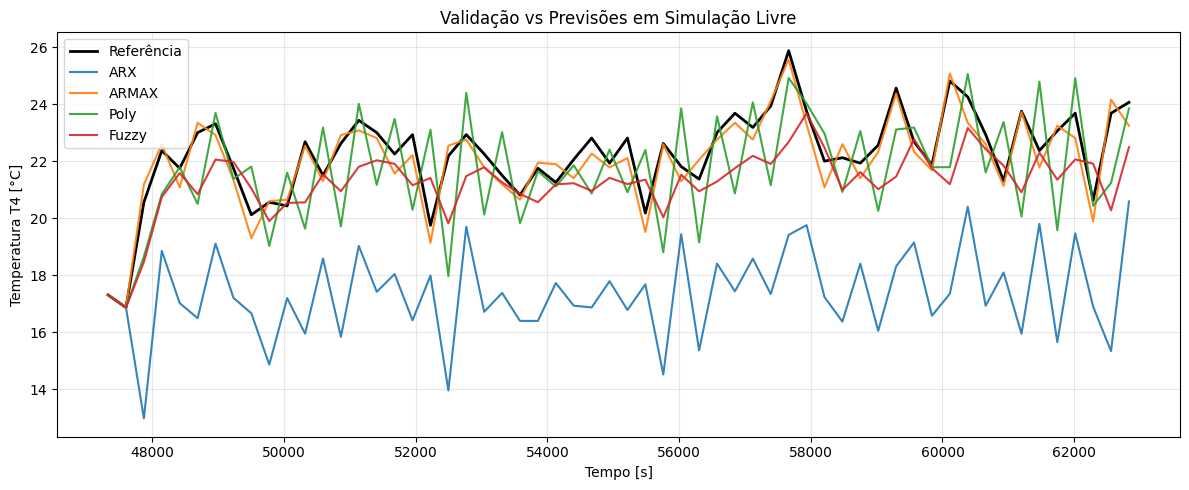

In [69]:
# Plot validation T4 and free-run predictions

# Time axis from validation dataframe
t_val = val_df['t'].to_numpy()

# Build/collect free-run predictions for available models
preds = {}
try:
    for name, params in models:
        sim = SystemSimulator(name, params, u_val, y_val)
        preds[name] = sim.run_horizon_simulation(horizon=N_val + 100)
except NameError:
    # Fallback: use existing y_free if models/SystemSimulator are not available
    preds = {'Model': y_free}

plt.figure(figsize=(12, 5))
plt.plot(t_val, y_val, label='Referência', color='k', linewidth=2)

for name, y_hat in preds.items():
    plt.plot(t_val, y_hat, label=f'{name}', alpha=0.9)

plt.title('Validação vs Previsões em Simulação Livre')
plt.xlabel('Tempo [s]')
plt.ylabel('Temperatura T4 [°C]')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('validacao.png', dpi=300)
plt.show()